# **Child Well-being - POSet creation**<br/>
**University: University of Milano-Bicocca**<br/>
**Master's Degree: Data Science (A.Y. 2025/2026)**<br/>
**Course: Data Science Lab**<br/>

---  
Use the Python Porting of R package `poseticDataAnalysis` by Avellone, De Capitani, Fattore.  
Added some implementations to work with Polars dataframes and handle `null` values ​​as uncertainty intervals in the hyperlattice.

**reference:**  
Fattore M., De Capitani L., Avellone A., Suardi A. (2024).  
*A fuzzy posetic toolbox for multi-criteria evaluation on ordinal data systems.*  
Annals of Operations Research. [doi:10.1007/s10479-024-06352-3](https://link.springer.com/article/10.1007/s10479-024-06352-3?utm_source=researchgate.net&utm_medium=article)

In [93]:
import sys; sys.path.insert(0, '..')
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import networkx as nx
import poset as P

---
## 0. Parameters summary -> `poset_from_polars`

| Parameter | Default | Description |
|-----------|---------|-------------|
| `col1` | `None` | First column to generate the ID |
| `col2` | `None` | Second column to generate the ID |
| `id_col` | `None` | Pre-existing ID (alternative to col1+col2) |
| `indicator_cols` | `None` | Indicator columns; if None -> all int |
| `higher_is_better` | `True` | High value = better position |
| `dominance_mode` | `'certain_or_possible'` | Type of dominance to calculate (certain, possible, certain_or_possible)  |
| `value_range` | `None` | Theoretical range `(min, max)` for null intervals |
| `max_null_frac` | `1.0` | Max null fraction to include a unit |
| `unit_sep` | `'_'` | ID separator |

**Dictionary key output returned:**
- `poset_certain` / `poset_possible` — the two POSets to use with all the library functions
- `intervals` — `{unit: {'lo': array, 'hi': array}}` — the region of each unit
- `confidence` — `{(a,b): float}` — reliability of each dominance pair
- `null_mask` — `{unit: bool array}` — where are the nulls

## 1. Import datasets

In [94]:
n_levels_macro = 3
# Import dataset
ind_2018 = pl.read_parquet(f'../data/040_indicators_macro_dim_{n_levels_macro}_level_2018.parquet')
# select a subset of columns for example purposes
#ind_2018 = ind_2018.select(['REF_AREA', 'TIME_PERIOD', 'A1_2', 'A3_3', 'B2_5', 'C1_5'])
ind_2015 = pl.read_parquet(f'../data/040_indicators_macro_dim_{n_levels_macro}_level_2015.parquet')
# select a subset of columns for example purposes
#ind_2015 = ind_2015.select(['REF_AREA', 'TIME_PERIOD', 'A1_2', 'A3_3', 'B2_5', 'C1_5'])
exp_2018 = pl.read_parquet('../data/040_public_expenditure_dim_discrete_4_level_2018.parquet') 
# select a subset of columns for example purposes
#exp_2018 = exp_2018.select(['REF_AREA', 'TIME_PERIOD', 'C2_1', 'C2_3', 'C4_4'])
exp_2015 = pl.read_parquet('../data/040_public_expenditure_dim_discrete_4_level_2015.parquet')
# select a subset of columns for example purposes
#exp_2015 = exp_2015.select(['REF_AREA', 'TIME_PERIOD', 'C2_1', 'C2_3', 'C4_4'])
datasets = [ind_2018, ind_2015, exp_2018, exp_2015]
print('Data loaded successfully')

Data loaded successfully


---

## 2. Data extration and POSet creation

Since the `POSet(elements, dom)` constructor accepts `elements` as a list of labels and `dom` as a list of pairs `(a, b)` with `a ≤ b`, I need to extract the two lists from the datasets.  
The remaining `null` values are not missing data to be imputed; instead, they are treated as structural uncertainty: the unit does not occupy a single point in the hyperlattice, but rather a region, namely all points compatible with the observed values.  

The function uses the following normalization:
- every unit **a** with `null` on indicator **k** is compatible with any value along that dimension
- therefore, **a** represents an interval in the hyperlattice: `[a_lower, a_upper]`, where `a_lower` has the `null` values replaced with the minimum possible values and `a_upper` with the maximum
- Dominance then becomes interval dominance:
   - `a ≤ certain b` if `a_upper ≤ b_lower` (certainly below)
   - `a ≤ possible b` if `a_lower ≤ b_upper` (possibly below)
   - otherwise, they are incomparable


In [95]:
# Extract elements and dominance from datasets
results = {}

for df in datasets:
    df_name = [k for k,v in globals().items() if v is df][0]
    print(f'Processing dataset [{df_name}]')
    result = P.poset_from_polars(
        df,
        col1='REF_AREA',      # area first element for ID
        col2='TIME_PERIOD',   # year second element for ID
        higher_is_better=True,
        dominance_mode='certain_or_possible',
    )
    results[df_name] = result

Processing dataset [ind_2018]
Processing dataset [ind_2015]
Processing dataset [exp_2018]
Processing dataset [exp_2015]


In [96]:
import pickle
import os

path = f"../data/050_posets_macro_dimensions_{n_levels_macro}_level.pkl"

with open(path, "wb") as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

### 2.0 Select the dataset to explore

In [97]:
result_sel = results['ind_2018'] # select the results for the dataset you want to explore

### 2.1 Ranges visualization

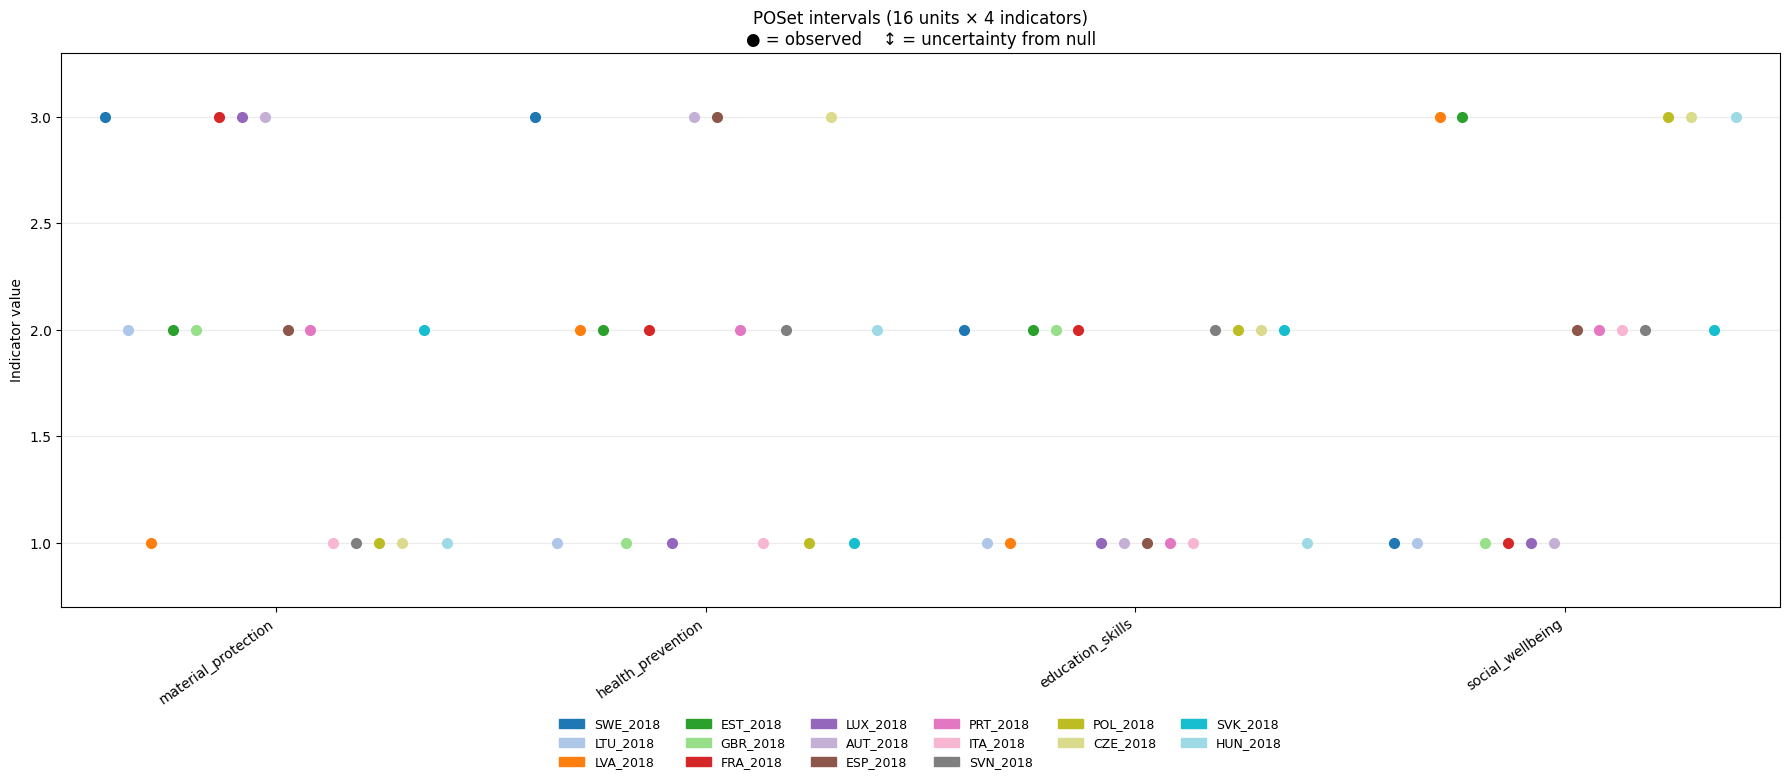

In [98]:
"""
Plot intervals for POSet elements.

Visualizes observed values (points) and uncertainty intervals (bars)
for each statistical unit across all indicators in a POSet result.

"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def plot_poset_intervals(
    result: dict,
    figsize: tuple = (18, 9),
    marker_size: float = 7,
    bar_width: float = 3.5,
    bar_alpha: float = 0.55,
    max_units: int | None = None,
    title: str | None = None,
    ylabel: str = "Indicator value",
    xlabel_rotation: int = 35,
    legend_ncol: int = 6,
    cmap_name: str = "tab20",
    y_padding: float = 0.3,
    grid_alpha: float = 0.25,
    save_path: str | None = None,
    dpi: int = 150,
):
    """
    Plot uncertainty intervals for POSet elements.

    Parameters
    ----------
    result : dict
        Output of ``poset_from_polars()``.
    figsize : tuple
    marker_size : float
    bar_width : float
        Line width of uncertainty bars.
    bar_alpha : float
    max_units : int, optional
        Limit the number of displayed units (sorted alphabetically).
    title : str, optional
    ylabel, xlabel_rotation, legend_ncol : display options
    cmap_name : str
        Matplotlib colormap (default: 'tab20').
    y_padding : float
        Vertical padding around data range.
    save_path : str, optional
        If given, save figure to this path.
    dpi : int
    """
    # ----- Extract data from result dict -----
    units = result["elements"]
    intervals = result["intervals"]
    null_masks = result["null_mask"]
    sel_indicators = result["indicator_cols"]
    n_ind = len(sel_indicators)

    if max_units is not None and len(units) > max_units:
        units = sorted(units)[:max_units]

    n_units = len(units)

    # ----- Y-axis limits from data -----
    all_lo = np.array([intervals[u]["lo"] for u in units])
    all_hi = np.array([intervals[u]["hi"] for u in units])
    y_min = np.nanmin(all_lo) - y_padding
    y_max = np.nanmax(all_hi) + y_padding

    # ----- Adaptive spacing -----
    # Prevent overlap: total width per indicator tick should stay < 0.9
    spacing = min(0.12, 0.85 / max(n_units, 1))

    # ----- Color palette -----
    cmap = plt.colormaps.get_cmap(cmap_name).resampled(n_units)
    colors = [cmap(i) for i in range(n_units)]

    # ----- Plot -----
    fig, ax = plt.subplots(figsize=figsize)
    for ui, unit in enumerate(units):
        lo = intervals[unit]["lo"]
        hi = intervals[unit]["hi"]
        nm = null_masks[unit]
        col = colors[ui]
        base_offset = (ui - n_units / 2 + 0.5) * spacing

        x_all = np.arange(n_ind) + base_offset
        
        # Observed value → solid dot
        obs_mask = ~nm
        if obs_mask.any():
            ax.scatter(
                x_all[obs_mask], lo[obs_mask],
                color=col, s=marker_size**2, zorder=3, marker="o",
            )
        
        # Null → uncertainty interval with end markers
        null_idx = np.where(nm)[0]
        for j in null_idx:
            ax.plot(
                [x_all[j], x_all[j]], [lo[j], hi[j]], "-",
                color=col, lw=bar_width, alpha=bar_alpha,
                solid_capstyle="round",
            )
        if len(null_idx) > 0:
            ax.scatter(x_all[null_idx], lo[null_idx], color=col,
                    s=(marker_size-1)**2, zorder=3, marker="v")
            ax.scatter(x_all[null_idx], hi[null_idx], color=col,
                    s=(marker_size-1)**2, zorder=3, marker="^")

    # ----- Axes formatting -----
    ax.set_xticks(range(n_ind))
    ax.set_xticklabels(sel_indicators, rotation=xlabel_rotation, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_ylim(y_min, y_max)
    ax.grid(axis="y", alpha=grid_alpha)
    ax.set_xlim(-0.5, n_ind - 0.5)

    if title is None:
        title = (
            f"POSet intervals ({n_units} units × {n_ind} indicators)\n"
            "● = observed    ↕ = uncertainty from null"
        )
    ax.set_title(title, fontsize=12)

    # ----- Legend -----
    patches = [
        mpatches.Patch(color=colors[i], label=units[i])
        for i in range(n_units)
    ]
    ax.legend(
        handles=patches,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=min(legend_ncol, n_units),
        frameon=False,
        fontsize=9,
    )

    plt.subplots_adjust(bottom=0.28)
    plt.tight_layout(rect=[0, 0.12, 1, 1])

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

    return fig, ax

fig, ax = plot_poset_intervals(result_sel)

# ----- Quick usage -----
# fig, ax = plot_poset_intervals(result_sel)
# fig, ax = plot_poset_intervals(result_sel, save_path="intervals.png")

### 2.2 Summary diagnostic
`interval_summary` returns the volume of the region of each unit:  
- for a country with no nulls it is 1 (point)  
- for a country with 3 nulls on range [1,5] it is 5^3 = 125 — a direct measure of how big its uncertainty zone is

In [99]:
summary = P.interval_summary(result_sel)
pl.Config.set_tbl_rows(-1)       
pl.Config.set_tbl_cols(-1)        
display(summary)
print()
print('Interpretation interval_volume:')
print('  → volume = product of the widths of each dimension (indicator)')
print('  → volume = 1   if no null values (point)')
print('  → volume > 1   if there are null values (region in the hypercube)')

unit,n_null,null_frac,interval_volume,is_point,n_certain_dom,n_possible_dom,mean_confidence
str,i64,f64,f64,bool,i64,i64,f64
"""SWE_2018""",0,0.0,1.0,true,0,0,null
"""LTU_2018""",0,0.0,1.0,true,9,9,1.0
"""LVA_2018""",0,0.0,1.0,true,3,3,1.0
"""EST_2018""",0,0.0,1.0,true,0,0,null
"""GBR_2018""",0,0.0,1.0,true,4,4,1.0
"""FRA_2018""",0,0.0,1.0,true,1,1,1.0
"""LUX_2018""",0,0.0,1.0,true,3,3,1.0
"""AUT_2018""",0,0.0,1.0,true,1,1,1.0
"""ESP_2018""",0,0.0,1.0,true,0,0,null



Interpretation interval_volume:
  → volume = product of the widths of each dimension (indicator)
  → volume = 1   if no null values (point)
  → volume > 1   if there are null values (region in the hypercube)


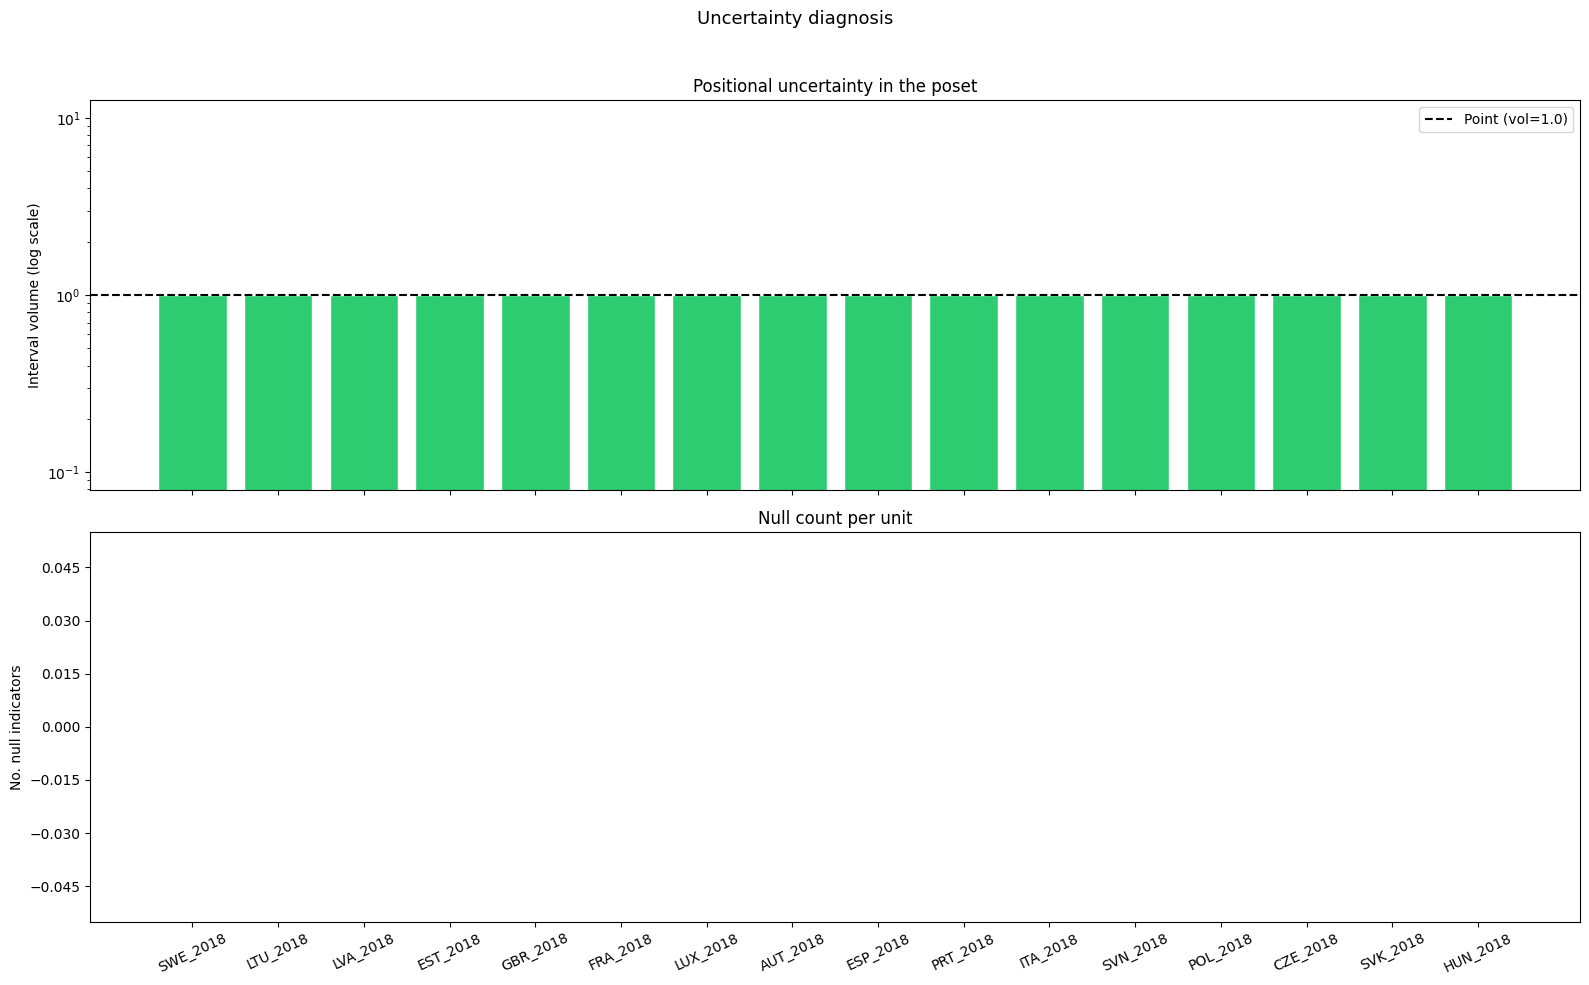

(<Figure size 1600x1000 with 2 Axes>,
 (<Axes: title={'center': 'Positional uncertainty in the poset'}, ylabel='Interval volume (log scale)'>,
  <Axes: title={'center': 'Null count per unit'}, ylabel='No. null indicators'>))

In [100]:
def plot_uncertainty_diagnosis(
    summary: "pl.DataFrame",
    figsize: tuple = (16, 10),
    point_volume: float = 1.0,
    sort_by: str = "volume",
    save_path: str | None = None,
    dpi: int = 150,
):
    """
    Two-panel diagnostic: interval volume and null count per unit.

    Parameters
    ----------
    summary : pl.DataFrame
        Output of ``interval_summary(result)``.
    figsize : tuple
    point_volume : float
        Threshold separating point-units from interval-units.
    sort_by : str
        'volume' (descending), 'nulls' (descending), or 'name' (alphabetical).
    save_path : str, optional
    dpi : int
    """
    units_s = summary["unit"].to_list()
    volumes = summary["interval_volume"].to_list()
    n_nulls = summary["n_null"].to_list()

    # --- Sort units ---
    if sort_by == "volume":
        order = sorted(range(len(volumes)), key=lambda i: volumes[i], reverse=True)
    elif sort_by == "nulls":
        order = sorted(range(len(n_nulls)), key=lambda i: n_nulls[i], reverse=True)
    elif sort_by == "name":
        order = sorted(range(len(units_s)), key=lambda i: units_s[i])
    else:
        order = list(range(len(units_s)))

    units_s = [units_s[i] for i in order]
    volumes = [volumes[i] for i in order]
    n_nulls = [n_nulls[i] for i in order]

    # --- Guard against log(0) ---
    safe_volumes = [max(v, 1e-10) for v in volumes]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=True)

    # --- Panel 1: Interval volume ---
    bar_colors = [
        "#e74c3c" if v > point_volume else "#2ecc71" for v in volumes
    ]
    ax1.bar(units_s, safe_volumes, color=bar_colors, edgecolor="white")
    ax1.axhline(
        point_volume, color="black", lw=1.5, ls="--",
        label=f"Point (vol={point_volume})",
    )
    ax1.set_ylabel("Interval volume (log scale)")
    ax1.set_yscale("log")
    ax1.set_title("Positional uncertainty in the poset")
    ax1.legend()

    # --- Panel 2: Null count ---
    ax2.bar(units_s, n_nulls, color="#3498db", edgecolor="white")
    ax2.set_ylabel("No. null indicators")
    ax2.set_title("Null count per unit")
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax2.tick_params(axis="x", rotation=25)

    fig.suptitle("Uncertainty diagnosis", fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    return fig, (ax1, ax2)

plot_uncertainty_diagnosis(summary)

## 3. POSet comparison - certain vs. possible

In [101]:
def plot_hasse(
    poset,
    title: str,
    ax,
    node_size: int = 2800,
    font_size: int = 9,
    arrow_size: int = 15,
    color_max: str = "#2ecc71",
    color_min: str = "#e74c3c",
    color_iso: str = "#f39c12",
    color_mid: str = "#3498db",
    layout_prog: str = "dot",
    rankdir: str = "BT",
    nodesep: float = 1.5,
    ranksep: float = 2.0,
    min_distance: float = 50.0,
    shorten_labels: bool = True,
    label_sep: str = "_",
):
    covers = poset.cover_relation()
    G = nx.DiGraph()
    G.add_nodes_from(poset.elements)
    G.add_edges_from(covers)

    try:
        layout = nx.nx_agraph.graphviz_layout(
            G, prog=layout_prog,
            args=(
                f"-Grankdir={rankdir} "
                f"-Gnodesep={nodesep} "
                f"-Granksep={ranksep}"
            ),
        )
    except Exception:
        layout = nx.kamada_kawai_layout(G, scale=500)

    # Post-process: push apart overlapping nodes
    layout = _separate_overlapping_nodes(layout, min_distance=min_distance)

    minimals = set(poset.minimals())
    maximals = set(poset.maximals())

    colors = []
    for n in poset.elements:
        is_min = n in minimals
        is_max = n in maximals
        if is_min and is_max:
            colors.append(color_iso)
        elif is_max:
            colors.append(color_max)
        elif is_min:
            colors.append(color_min)
        else:
            colors.append(color_mid)

    if shorten_labels:
        label_map = {
            e: e.split(label_sep)[0] if label_sep in e else e
            for e in poset.elements
        }
    else:
        label_map = {e: e for e in poset.elements}

    nx.draw_networkx_edges(
        G, layout, ax=ax,
        edge_color="#999",
        arrows=True,
        arrowsize=arrow_size,
        arrowstyle="-|>",
        connectionstyle="arc3,rad=0.1",
        width=1.5,
        alpha=0.5,
        min_source_margin=25,
        min_target_margin=25,
    )

    nx.draw_networkx_nodes(
        G, layout, ax=ax,
        node_color=colors,
        node_size=node_size,
        edgecolors="white",
        linewidths=2.0,
    )

    nx.draw_networkx_labels(
        G, layout, ax=ax,
        labels=label_map,
        font_color="white",
        font_size=font_size,
        font_weight="bold",
    )

    ax.set_title(title, fontsize=13, pad=20)
    ax.axis("off")
    ax.margins(0.15)


def _separate_overlapping_nodes(
    layout: dict,
    min_distance: float = 50.0,
    max_iterations: int = 100,
) -> dict:
    """
    Iteratively push apart nodes that are closer than min_distance.
    Preserves the general structure from graphviz while eliminating overlaps.
    """
    pos = {k: np.array(v, dtype=float) for k, v in layout.items()}
    nodes = list(pos.keys())
    n = len(nodes)

    for _ in range(max_iterations):
        moved = False
        for i in range(n):
            for j in range(i + 1, n):
                a, b = nodes[i], nodes[j]
                delta = pos[b] - pos[a]
                dist = np.linalg.norm(delta)

                if dist < min_distance:
                    if dist < 1e-6:
                        # Nearly identical positions: push horizontally
                        delta = np.array([min_distance, 0.0])
                        dist = min_distance

                    # Push each node away by half the needed distance
                    direction = delta / dist
                    shift = (min_distance - dist) / 2.0 * direction
                    pos[a] -= shift
                    pos[b] += shift
                    moved = True

        if not moved:
            break

    return {k: tuple(v) for k, v in pos.items()}


def plot_hasse_comparison(
    result: dict,
    suptitle: str = "Comparison of POSet certain vs possible",
    layout: str = "horizontal",
    figsize: tuple | None = None,
    save_path: str | None = None,
    dpi: int = 150,
    **hasse_kwargs,
):
    """
    Side-by-side (or stacked) Hasse diagrams for certain and possible POSets.
    """
    if layout == "horizontal":
        nrows, ncols = 1, 2
        figsize = figsize or (28, 16)
    else:
        nrows, ncols = 2, 1
        figsize = figsize or (18, 32)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)

    plot_hasse(
        result["poset_certain"],
        "POSet CERTAIN\n(a ≤ b in every scenario)",
        axes[0],
        **hasse_kwargs,
    )
    plot_hasse(
        result["poset_possible"],
        "POSet POSSIBLE\n(a ≤ b in at least one scenario)",
        axes[1],
        **hasse_kwargs,
    )

    patches = [
        mpatches.Patch(color="#2ecc71", label="Maximal"),
        mpatches.Patch(color="#e74c3c", label="Minimal"),
        mpatches.Patch(color="#f39c12", label="Isolated (min & max)"),
        mpatches.Patch(color="#3498db", label="Intermediate"),
    ]
    fig.legend(
        handles=patches, loc="lower center",
        ncol=4, fontsize=11, frameon=False,
    )
    fig.suptitle(suptitle, fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    return fig, axes

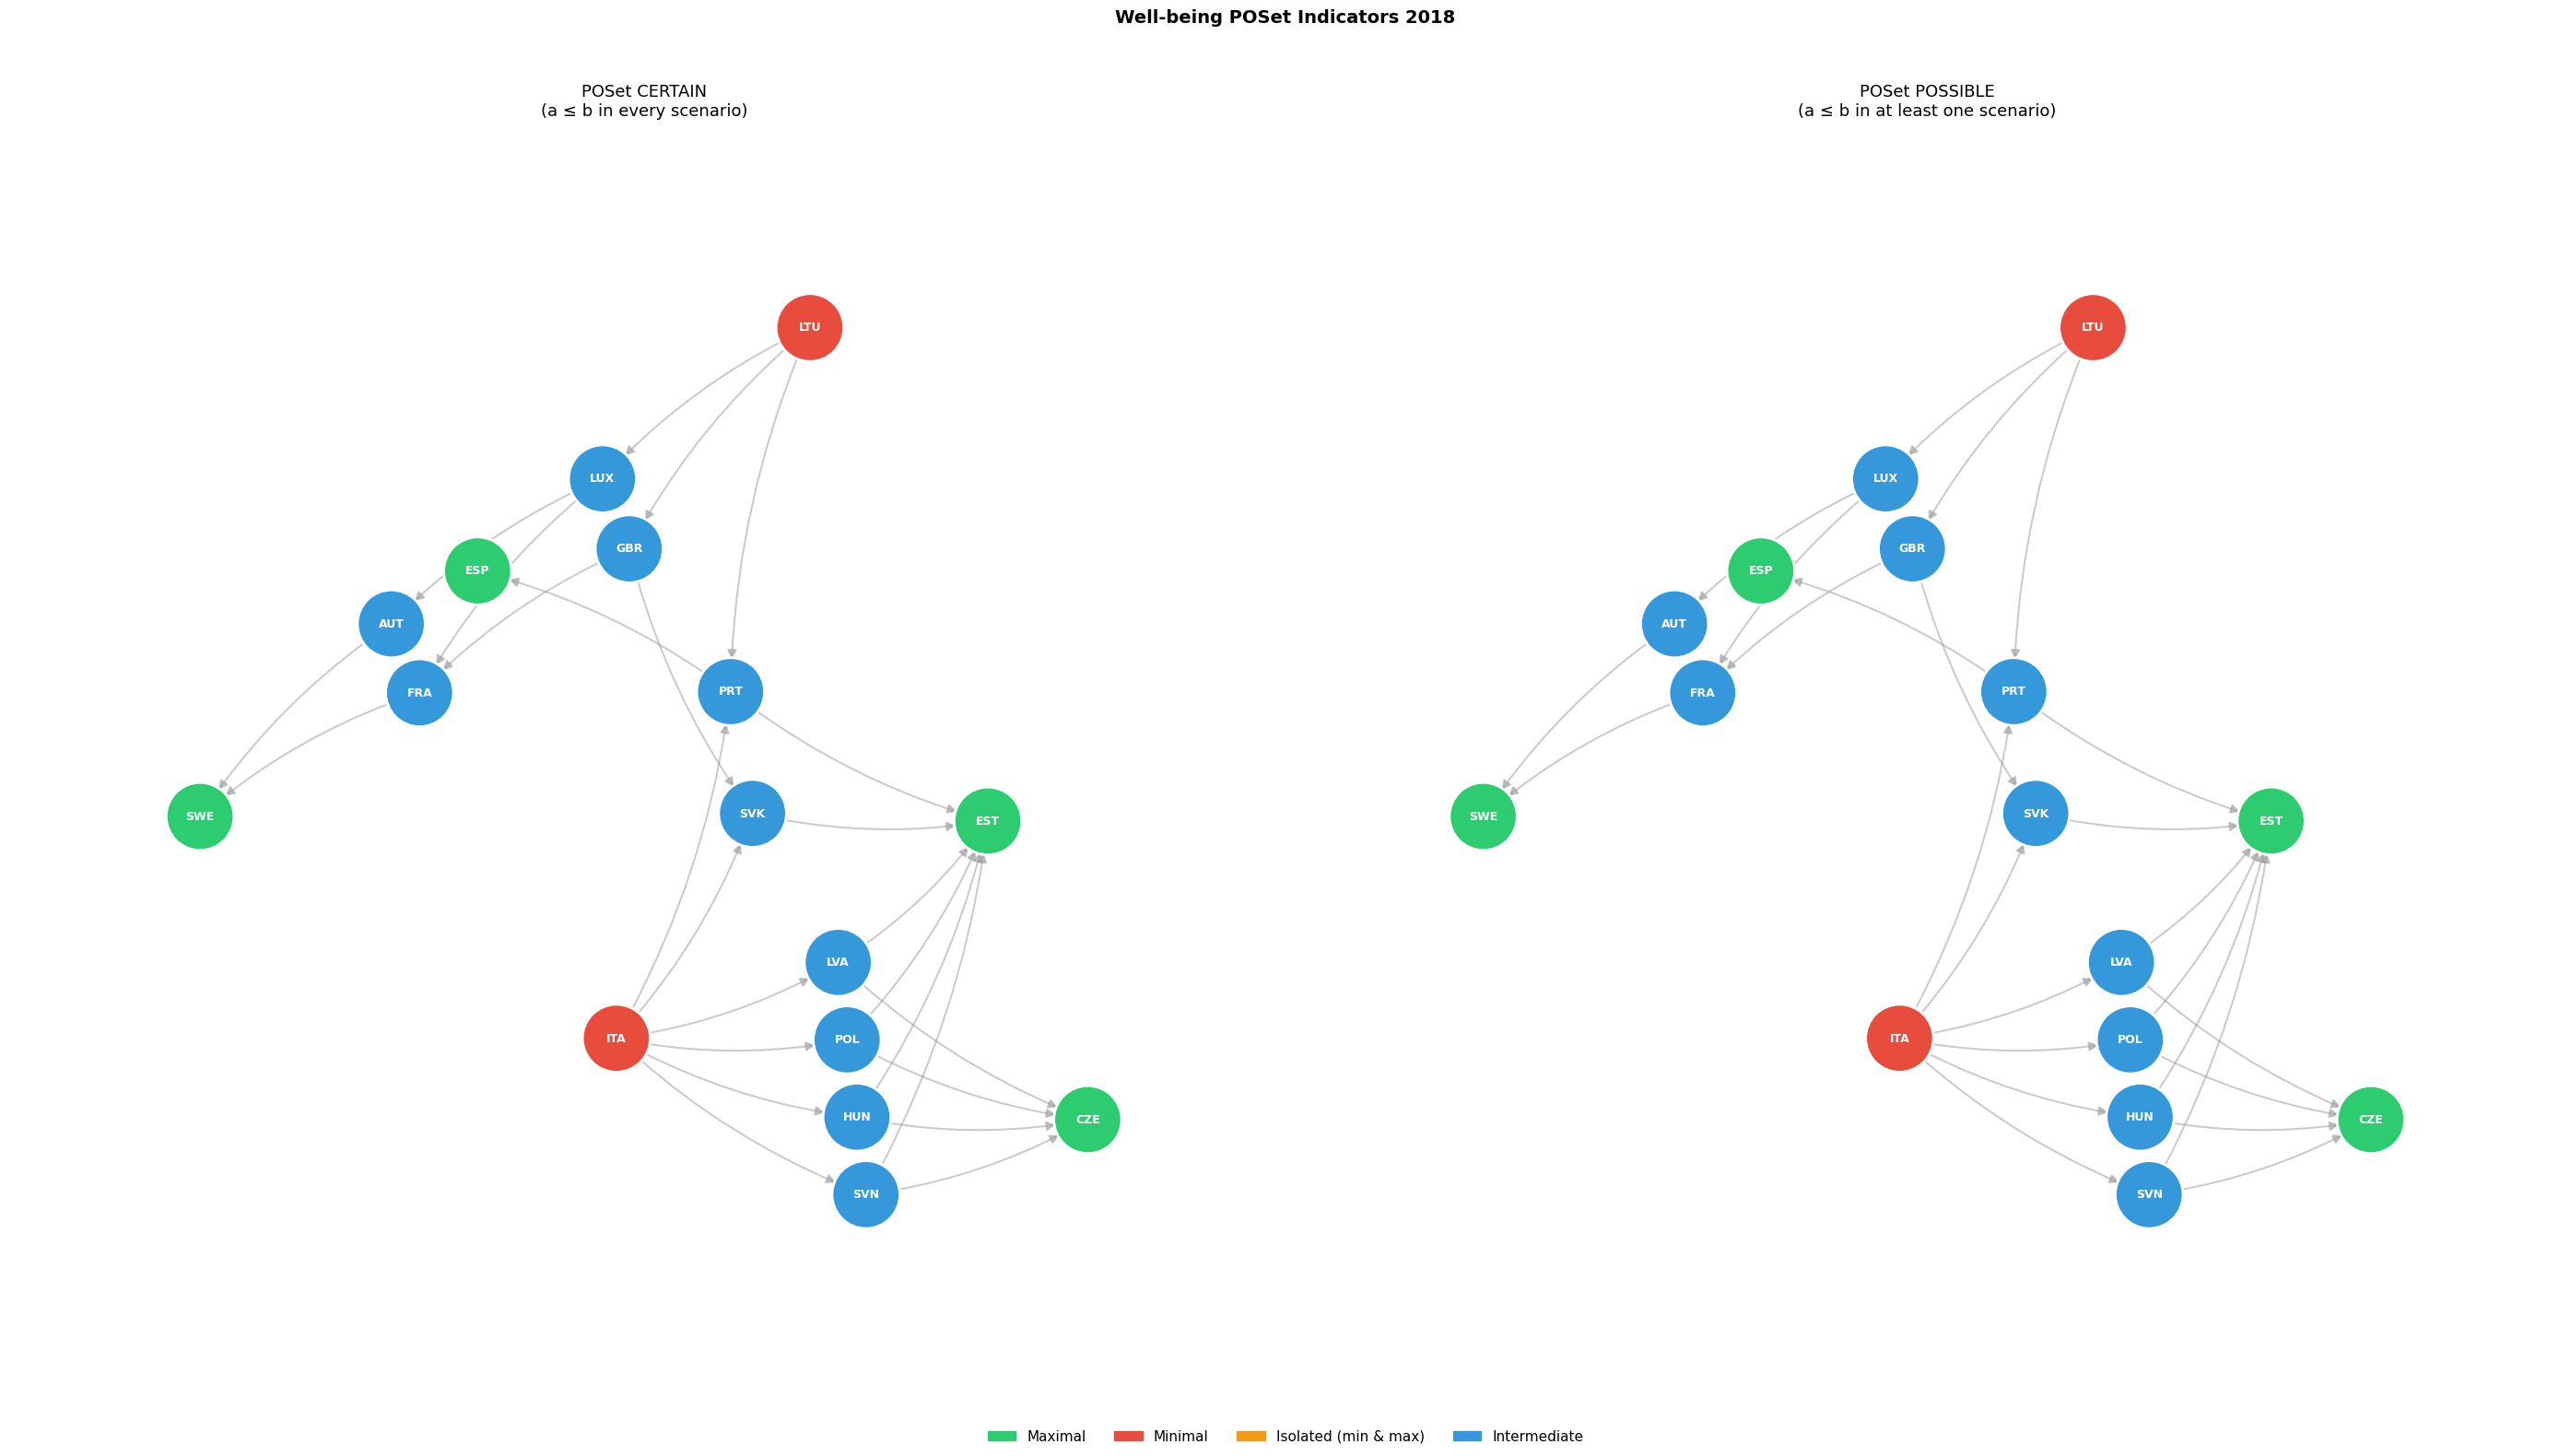

In [102]:
label = 'Indicators 2015' if result_sel == results['ind_2015'] else 'Expenditures 2015' if result_sel == results['exp_2015'] else 'Indicators 2018' if result_sel == results['ind_2018'] else 'Expenditures 2018'


fig, axes = plot_hasse_comparison(
    result_sel,
    suptitle= f"Well-being POSet {label}",
    min_distance=60.0,
)

### 3.1 Confidence as a measure of dominance reliability

In [103]:
print('Intervals:')
for uid in result_sel['elements']:
    lo = result_sel['intervals'][uid]['lo']
    hi = result_sel['intervals'][uid]['hi']
    nm = result_sel['null_mask'][uid]
    inds = result_sel['indicator_cols']
    print(f'  {uid}:', end=' ')
    for j, ind in enumerate(inds):
        if nm[j]:
            print(f'{ind}=[{lo[j]:.0f},{hi[j]:.0f}]', end=' ')
        else:
            print(f'{ind}={lo[j]:.0f}', end=' ')
    print()

Intervals:
  SWE_2018: material_protection=3 health_prevention=3 education_skills=2 social_wellbeing=1 
  LTU_2018: material_protection=2 health_prevention=1 education_skills=1 social_wellbeing=1 
  LVA_2018: material_protection=1 health_prevention=2 education_skills=1 social_wellbeing=3 
  EST_2018: material_protection=2 health_prevention=2 education_skills=2 social_wellbeing=3 
  GBR_2018: material_protection=2 health_prevention=1 education_skills=2 social_wellbeing=1 
  FRA_2018: material_protection=3 health_prevention=2 education_skills=2 social_wellbeing=1 
  LUX_2018: material_protection=3 health_prevention=1 education_skills=1 social_wellbeing=1 
  AUT_2018: material_protection=3 health_prevention=3 education_skills=1 social_wellbeing=1 
  ESP_2018: material_protection=2 health_prevention=3 education_skills=1 social_wellbeing=2 
  PRT_2018: material_protection=2 health_prevention=2 education_skills=1 social_wellbeing=2 
  ITA_2018: material_protection=1 health_prevention=1 educa

In [104]:
print('Certain dominance:', result_sel['dom_certain'])
print('Possible dominance:', result_sel['dom_possible'])
print()
print('Confidence (indicators with no null on either unit):')
for pair, c in sorted(result_sel['confidence'].items()):
    kind = 'CERTAIN' if pair in set(result_sel['dom_certain']) else 'Only Possible'
    print(f'  {pair[0]} ≤ {pair[1]}  →  {c:.0%}  [{kind}]')

Certain dominance: [('LTU_2018', 'SWE_2018'), ('LTU_2018', 'EST_2018'), ('LTU_2018', 'GBR_2018'), ('LTU_2018', 'FRA_2018'), ('LTU_2018', 'LUX_2018'), ('LTU_2018', 'AUT_2018'), ('LTU_2018', 'ESP_2018'), ('LTU_2018', 'PRT_2018'), ('LTU_2018', 'SVK_2018'), ('LVA_2018', 'EST_2018'), ('LVA_2018', 'CZE_2018'), ('LVA_2018', 'HUN_2018'), ('GBR_2018', 'SWE_2018'), ('GBR_2018', 'EST_2018'), ('GBR_2018', 'FRA_2018'), ('GBR_2018', 'SVK_2018'), ('FRA_2018', 'SWE_2018'), ('LUX_2018', 'SWE_2018'), ('LUX_2018', 'FRA_2018'), ('LUX_2018', 'AUT_2018'), ('AUT_2018', 'SWE_2018'), ('PRT_2018', 'EST_2018'), ('PRT_2018', 'ESP_2018'), ('ITA_2018', 'LVA_2018'), ('ITA_2018', 'EST_2018'), ('ITA_2018', 'ESP_2018'), ('ITA_2018', 'PRT_2018'), ('ITA_2018', 'SVN_2018'), ('ITA_2018', 'POL_2018'), ('ITA_2018', 'CZE_2018'), ('ITA_2018', 'SVK_2018'), ('ITA_2018', 'HUN_2018'), ('SVN_2018', 'EST_2018'), ('SVN_2018', 'CZE_2018'), ('POL_2018', 'EST_2018'), ('POL_2018', 'CZE_2018'), ('SVK_2018', 'EST_2018'), ('HUN_2018', 'LVA_

*This notebook is licensed under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).*